Based on the xmls extracted from the cat12 derivatives, analyze the quality information per session collected using cat12_xml_parser.py and qc_df_generator.py

In [1]:
import pandas as pd
import numpy as np 
import os
import xml.etree.ElementTree as ET
import src.cleaning_funcs as cf
from src.qc_df_generator import extract_cat12_metrics_wide
from pathlib import Path
import re

### Load approved scans

In [2]:
approved_df = pd.read_pickle('/home/gaia/Projects/legacy_data/best_combined_gm_volumes.pkl')

In [3]:
print(f"columns of approved_df: {list(approved_df.columns)}")

columns of approved_df: ['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3', 'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob', 'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'unnamed: 0', 'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path', 'estimated_critical_info', 'scan_date', 'file_path', 'scan_year', 'classification_label']


In [4]:
# --- 1. Load and Clean Your Manually Approved DF ---
# Enforce string types on IDs to prevent formatting mismatches
approved_df['subject_id'] = approved_df['subject_id'].astype(str)
approved_df['session_id'] = approved_df['session_id'].astype(str)

# Align manufacturer and institute in all caps and replace spaces with underscores
approved_df['manufacturer'] = approved_df['manufacturer'].str.upper().str.replace(" ", "_")
approved_df['institute'] = approved_df['institute'].str.upper().str.replace(" ", "_")

# Pre-calculate the combined 'super_batch' column in the approved df
if 'super_batch' not in approved_df.columns:
    approved_df['super_batch'] = approved_df['institute'].str.strip() + "_" + approved_df['manufacturer'].str.strip()

# remove duplicates in approved_df based on subject_id and session_id
approved_df = approved_df.drop_duplicates(subset=['subject_id', 'session_id'])

# Convert to a set for fast O(1) lookup
approved_scans_set = set(zip(approved_df['subject_id'], approved_df['session_id']))

print(f"✅ Successfully loaded approval list. Total unique manually approved scans: {len(approved_scans_set)}")


# --- 2. Extract Data Across Sources ---
data_sources = {
    "snbb": Path("/home/gaia/Projects/legacy_data/QC_xmls"),
    "gnbb": Path("/home/gaia/Projects/legacy_data/BIDS_nii_output/derivatives/CAT12.9_2577"),
    "BIDS_over_thirties": Path("/home/gaia/Projects/HardDriveOutput/BIDS_over_thirties/derivatives/CAT12.9_2577"),
    "BIDS_thirties": Path("/home/gaia/Projects/HardDriveOutput/BIDS_thirties/derivatives/CAT12.9_2577"),
    "BIDS_under_thirties": Path("/home/gaia/Projects/HardDriveOutput/BIDS_under_thirties/derivatives/CAT12.9_2577")
}

all_dfs = []

for source_name, dir_path in data_sources.items():
    if dir_path.exists():
        print(f"Processing source '{source_name}'...")
        
        # CHOOSE VALIDATION STRATEGY: 
        # If source is snbb, pass None to bypass validation and extract everything
        current_filter = None if source_name == "snbb" else approved_scans_set
        
        source_df = extract_cat12_metrics_wide(dir_path, source_name, approved_scans_set=current_filter)
        print(f"  --> Extracted {len(source_df)} scans.")
        all_dfs.append(source_df)
    else:
        print(f"⚠️ Path not found: {dir_path}")

# Concatenate raw quality metrics
raw_qc_df = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()


# --- 3. Dynamically Add 'snbb' metadata to approved_df ---
# Since we bypassed the approval list for snbb, they won't be in approved_df. 
# We pull their IDs directly from the extracted raw_qc_df and append them to approved_df before the merge.
snbb_scans = raw_qc_df[raw_qc_df['source'] == 'snbb'][['subject_id', 'session_id']].copy()

if not snbb_scans.empty:
    # Since snbb scans bypassed the approved_df, we set default metadata values for them
    snbb_scans['institute'] = 'TEL-AVIV_UNIVERSITY'
    snbb_scans['manufacturer'] = 'SIEMENS'
    snbb_scans['super_batch'] = 'TEL-AVIV_UNIVERSITY_SIEMENS'
    
    # Append them to our master approved metadata reference
    approved_df = pd.concat([approved_df, snbb_scans], ignore_index=True).drop_duplicates(subset=['subject_id', 'session_id'])


# --- 4. Merge Data ---
# Perform the inner merge to bring in 'institute', 'manufacturer', and 'super_batch' 
final_qc_df = pd.merge(
    approved_df[['subject_id', 'session_id', 'institute', 'manufacturer', 'super_batch']], 
    raw_qc_df, 
    on=['subject_id', 'session_id'], 
    how='inner'
)

# Reorder columns to put your metadata up front
base_cols = ['subject_id', 'session_id', 'institute', 'manufacturer', 'super_batch', 'file_name', 'source']
metric_cols = [c for c in final_qc_df.columns if c not in base_cols]
final_qc_df = final_qc_df[base_cols + sorted(metric_cols)]

print(f"\n✅ Merge complete! Total matched scans (including all snbb): {len(final_qc_df)}")
final_qc_df.head()

✅ Successfully loaded approval list. Total unique manually approved scans: 4781
Processing source 'snbb'...
  --> Extracted 4508 scans.
Processing source 'gnbb'...
  --> Extracted 26 scans.
Processing source 'BIDS_over_thirties'...
  --> Extracted 234 scans.
Processing source 'BIDS_thirties'...
  --> Extracted 224 scans.
Processing source 'BIDS_under_thirties'...
  --> Extracted 469 scans.

✅ Merge complete! Total matched scans (including all snbb): 5461


,subject_id,session_id,institute,manufacturer,super_batch,file_name,source,ICR,IQR,NCR,...,tissue_mnr_4,tissue_std_1,tissue_std_2,tissue_std_3,tissue_std_4,tissue_stdr_1,tissue_stdr_2,tissue_stdr_3,tissue_stdr_4,tissue_weighting
0,ls191,20070322,ICHILOV_TEL_AVIV,GE_MEDICAL_SYSTEMS,ICHILOV_TEL_AVIV_GE_MEDICAL_SYSTEMS,cat_sub-ls191_ses-20070322_T1w.xml,gnbb,1.355093,2.214870,1.667469,...,1.0,6.100227,2.123387,1.005899,1.137912,0.000530,0.000284,0.000123,0.000082,T1
1,ls191,20071021,ICHILOV_TEL_AVIV,GE_MEDICAL_SYSTEMS,ICHILOV_TEL_AVIV_GE_MEDICAL_SYSTEMS,cat_sub-ls191_ses-20071021_T1w.xml,gnbb,1.042253,1.981059,1.745138,...,1.0,6.617951,1.329806,1.001996,1.095602,0.000304,0.000113,0.000068,0.000049,T1
2,ls097,20060618,ICHILOV_TEL_AVIV,GE_MEDICAL_SYSTEMS,ICHILOV_TEL_AVIV_GE_MEDICAL_SYSTEMS,cat_sub-ls097_ses-20060618_T1w.xml,gnbb,1.559625,1.976420,1.277211,...,1.0,8.624000,1.065136,1.006929,1.148963,0.011005,0.000086,0.000062,0.000041,T1
3,ls194,20030915,ICHILOV_TEL_AVIV,GE_MEDICAL_SYSTEMS,ICHILOV_TEL_AVIV_GE_MEDICAL_SYSTEMS,cat_sub-ls194_ses-20030915_T1w.xml,gnbb,0.807313,2.541063,1.144674,...,1.0,5.533097,1.006953,1.000950,1.099335,0.002972,0.000737,0.000781,0.000545,T1
4,ls113,20070130,ICHILOV_TEL_AVIV,GE_MEDICAL_SYSTEMS,ICHILOV_TEL_AVIV_GE_MEDICAL_SYSTEMS,cat_sub-ls113_ses-20070130_T1w.xml,gnbb,2.798921,2.385043,2.521786,...,1.0,8.624000,3.616692,1.001677,1.094343,0.007583,0.000195,0.000072,0.000047,T1


### Define sources of xml (cat12 derivative paths)

# Analysis

### EDA

In [5]:
print(f"columns in final_df: {list(final_qc_df.columns)}")

final_qc_df.info()

columns in final_df: ['subject_id', 'session_id', 'institute', 'manufacturer', 'super_batch', 'file_name', 'source', 'ICR', 'IQR', 'NCR', 'SIQR', 'SIQR3rms2', 'SIQR4rms2', 'SIQR4rms8', 'SurfaceDefectArea', 'SurfaceDefectNumber', 'SurfaceEulerNumber', 'SurfaceIntensityRMSE', 'SurfacePositionRMSE', 'contrast', 'contrastr', 'res_BB', 'res_ECR', 'res_RMS', 'res_vx_vol_1', 'res_vx_vol_2', 'res_vx_vol_3', 'res_vx_voli_1', 'res_vx_voli_2', 'res_vx_voli_3', 'software', 'tissue_mn_1', 'tissue_mn_2', 'tissue_mn_3', 'tissue_mn_4', 'tissue_mnr_1', 'tissue_mnr_2', 'tissue_mnr_3', 'tissue_mnr_4', 'tissue_std_1', 'tissue_std_2', 'tissue_std_3', 'tissue_std_4', 'tissue_stdr_1', 'tissue_stdr_2', 'tissue_stdr_3', 'tissue_stdr_4', 'tissue_weighting']
<class 'pandas.DataFrame'>
RangeIndex: 5461 entries, 0 to 5460
Data columns (total 48 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            5461 non-null   str    
 1   sess

In [6]:
# remove entries with nan from final_qc_df
final_qc_df = final_qc_df.dropna()

print(f"unique batches are: {final_qc_df['super_batch'].unique()}")

unique batches are: ['ICHILOV_TEL_AVIV_GE_MEDICAL_SYSTEMS' 'TEL-AVIV_UNIVERSITY_SIEMENS'
 'SHEBA__MEDICAL__CENTER_GE_MEDICAL_SYSTEMS']


### anova between batches for quality measures

In [ ]:
# 4. Iterate over your list

# Overall composite image quality ratings
GLOBAL_RATINGS = [
    'IQR', 
    'SIQR', 
    'SIQR3rms2', 
    'SIQR4rms2', 
    'SIQR4rms8'
]

# Noise and spatial inhomogeneity markers (Lower is typically better)
NOISE_AND_INHOMOGENEITY = [
    'NCR', 
    'ICR'
]

# Spatial resolution, voxel geometry, and field-of-view metrics
RESOLUTION_AND_GEOMETRY = [
    'res_RMS', 
    'res_BB', 
    'res_ECR', 
    'res_vx_vol_1', 
    'res_vx_vol_2', 
    'res_vx_vol_3', 
    'res_vx_voli_1', 
    'res_vx_voli_2', 
    'res_vx_voli_3'
]

# Cortical surface mesh reconstruction and defect metrics
SURFACE_METRICS = [
    'SurfaceEulerNumber', 
    'SurfaceDefectNumber', 
    'SurfaceDefectArea', 
    'SurfaceIntensityRMSE', 
    'SurfacePositionRMSE'
]

# Absolute and relative contrast between tissue classes
CONTRAST_METRICS = [
    'contrast', 
    'contrastr', 
    'tissue_weighting'
]

# Tissue segment intensity distributions (1=GM, 2=WM, 3=CSF, 4=Background)
# Means (mn), Standard Deviations (std), and Normalized versions (mnr, stdr)
TISSUE_INTENSITIES = [
    'tissue_mn_1', 'tissue_mn_2', 'tissue_mn_3', 'tissue_mn_4', 
    'tissue_mnr_1', 'tissue_mnr_2', 'tissue_mnr_3', 'tissue_mnr_4', 
    'tissue_std_1', 'tissue_std_2', 'tissue_std_3', 'tissue_std_4', 
    'tissue_stdr_1', 'tissue_stdr_2', 'tissue_stdr_3', 'tissue_stdr_4'
]

# Master list combining all numerical metrics for broad loops
ALL_NUMERICAL_METRICS = (
    GLOBAL_RATINGS + 
    NOISE_AND_INHOMOGENEITY + 
    RESOLUTION_AND_GEOMETRY + 
#    SURFACE_METRICS + 
    CONTRAST_METRICS + 
    TISSUE_INTENSITIES
)

In [8]:
# Shortlist of a few relevant measures 
shortlist = ['SIQR', 'NCR', 'ICR', 'tissue_mn_1', 'tissue_std_1', 'res_RMS']


--- Confounding Check (Batch vs. Siqr) ---


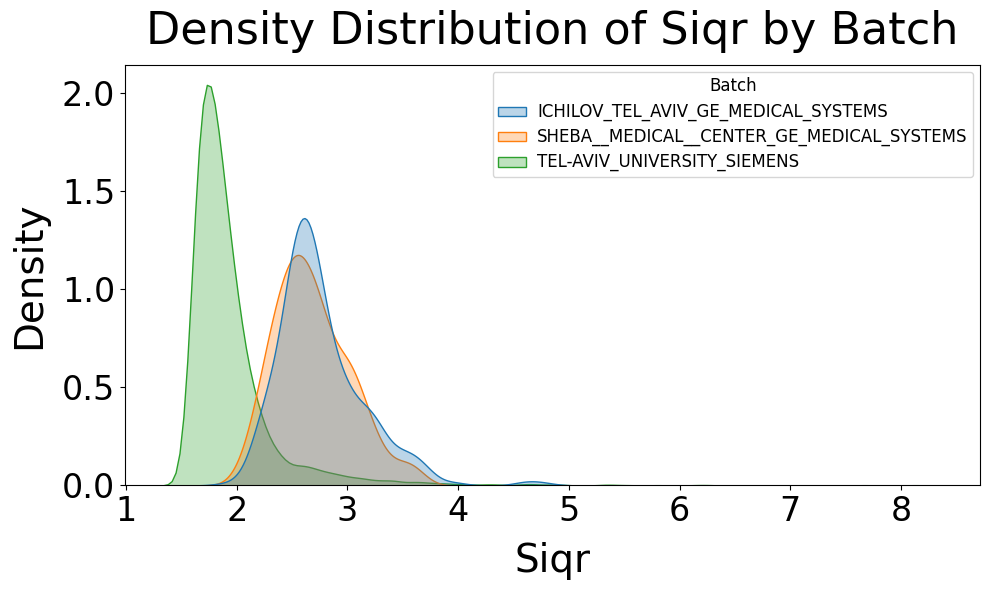

ANOVA Degrees of Freedom: between groups = 2, within groups = 5351
ANOVA F-statistic: 1142.8261
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. SIQR differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.

--- Confounding Check (Batch vs. Ncr) ---


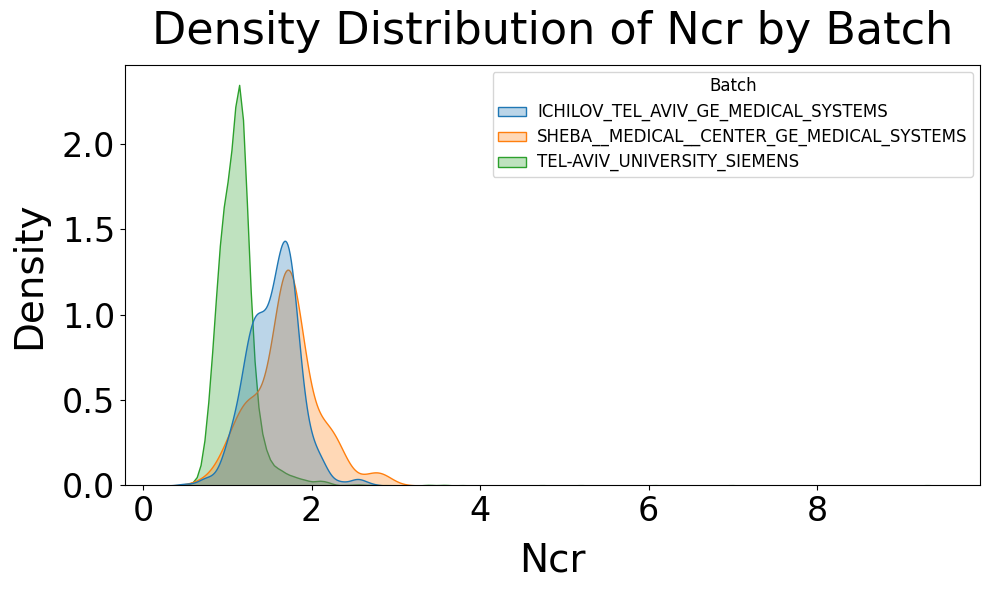

ANOVA Degrees of Freedom: between groups = 2, within groups = 5351
ANOVA F-statistic: 753.7785
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. NCR differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.

--- Confounding Check (Batch vs. Icr) ---


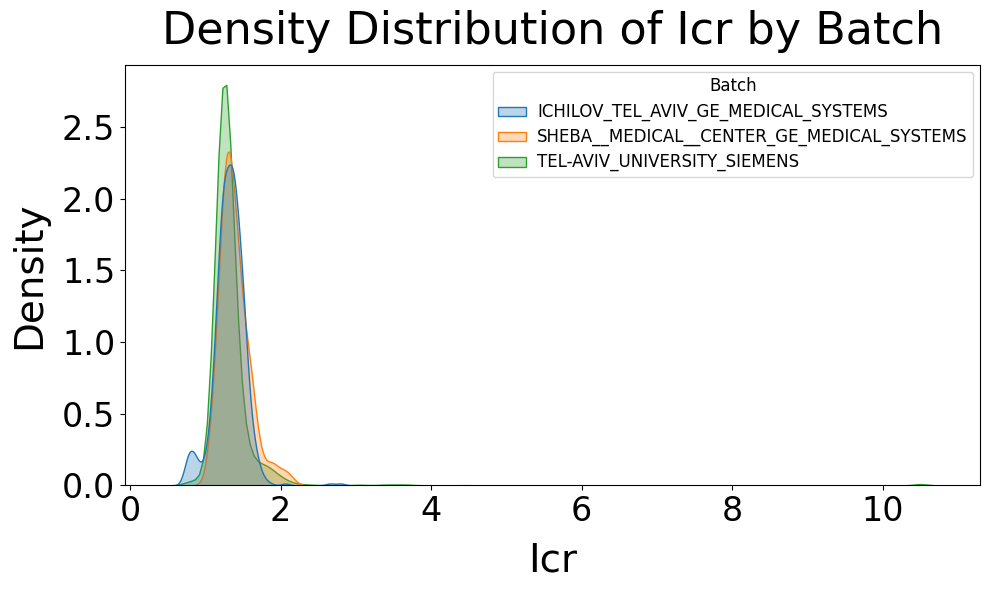

ANOVA Degrees of Freedom: between groups = 2, within groups = 5351
ANOVA F-statistic: 1.4188
ANOVA p-value: 0.2421
PASS: No significant difference in ICR across batches.

--- Confounding Check (Batch vs. Tissue Mn 1) ---


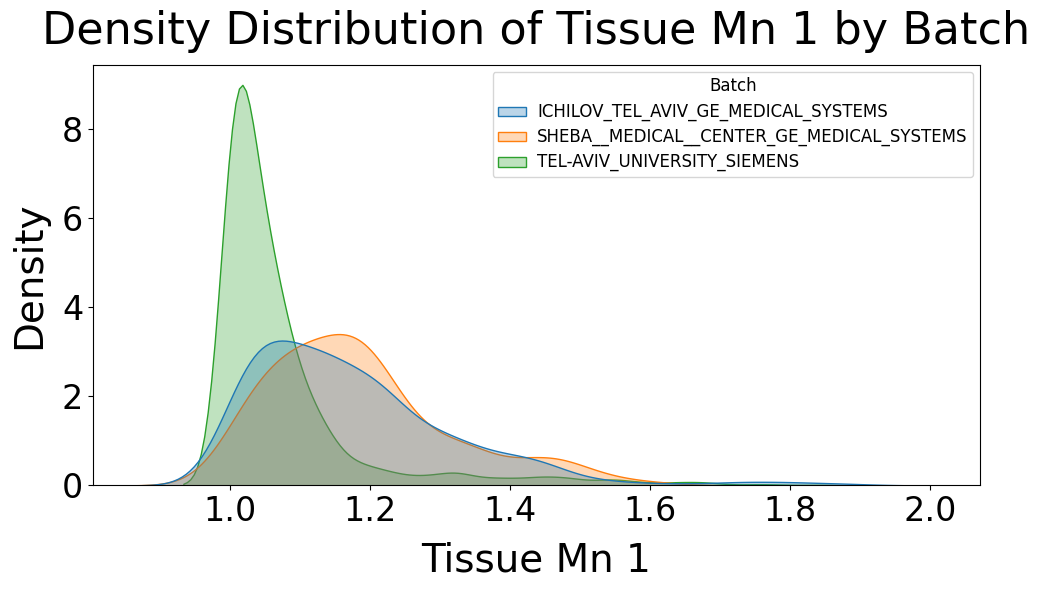

ANOVA Degrees of Freedom: between groups = 2, within groups = 5351
ANOVA F-statistic: 211.0560
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. tissue_mn_1 differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.

--- Confounding Check (Batch vs. Tissue Std 1) ---


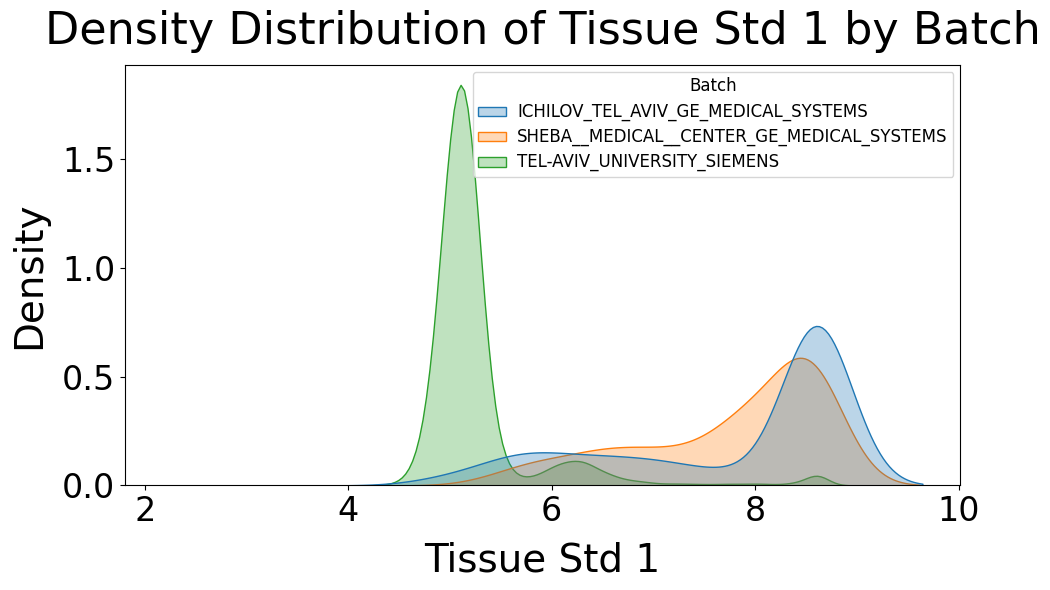

ANOVA Degrees of Freedom: between groups = 2, within groups = 5351
ANOVA F-statistic: 4065.2973
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. tissue_std_1 differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.

--- Confounding Check (Batch vs. Res Rms) ---


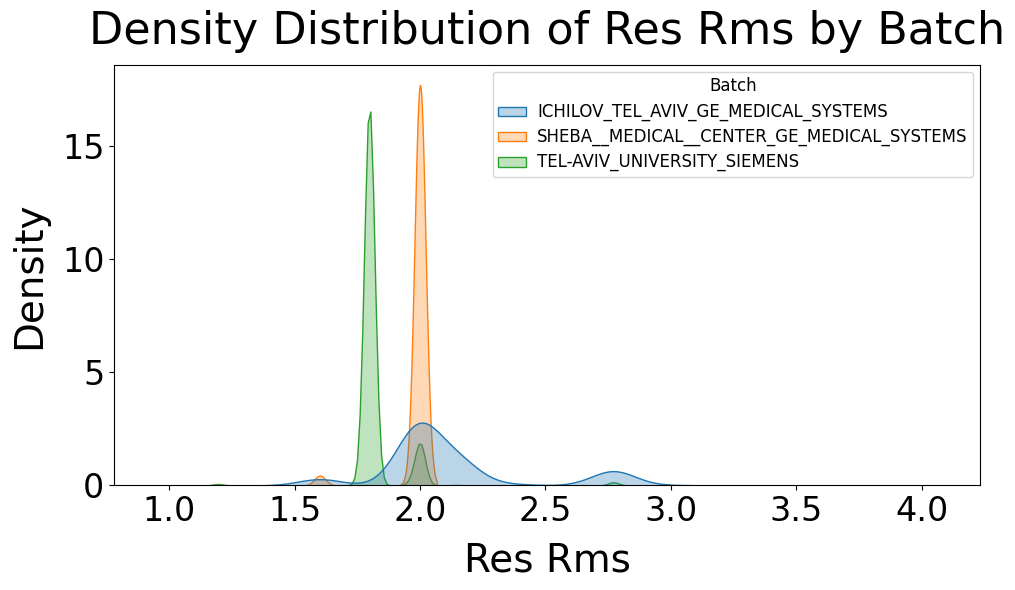

ANOVA Degrees of Freedom: between groups = 2, within groups = 5351
ANOVA F-statistic: 1129.0162
ANOVA p-value: 0.0000
ALERT: Strong confounding detected. res_RMS differs significantly across batches.
NeuroCombat will need to work harder to separate biological variance from site effects.


In [9]:
for var in shortlist:
    cf.check_confounding(final_qc_df, var, use_numeric_labels = False, legend_size=12)

In [ ]:
# make sure the resolution, noise, bias and IQR scores are high enough (under 3.5)

# per batch, print a summary report of SIQR - min, max, mean, std
for batch in final_qc_df['super_batch'].unique():
    batch_df = final_qc_df[final_qc_df['super_batch'] == batch]
    print(f"Batch: {batch}")
    print(f"  Min SIQR: {batch_df['SIQR'].min()}")
    print(f"  Max SIQR: {batch_df['SIQR'].max()}")
    print(f"  Mean SIQR: {batch_df['SIQR'].mean()}")
    print(f"  Std SIQR: {batch_df['SIQR'].std()}")

Batch: ICHILOV_TEL_AVIV_GE_MEDICAL_SYSTEMS
  Min SIQR: 1.88593807070438
  Max SIQR: 4.79299252555106
  Mean SIQR: 2.758857715447854
  Std SIQR: 0.3917439073966947
Batch: TEL-AVIV_UNIVERSITY_SIEMENS
  Min SIQR: 1.5740835217072
  Max SIQR: 8.12964889873256
  Mean SIQR: 1.936441394592246
  Std SIQR: 0.42054137492779997
Batch: SHEBA__MEDICAL__CENTER_GE_MEDICAL_SYSTEMS
  Min SIQR: 2.04854344829831
  Max SIQR: 3.6167464946089
  Mean SIQR: 2.683047468930681
  Std SIQR: 0.3361342382421188


In [ ]:
bad_scans = final_qc_df[final_qc_df['SIQR'] >= 3.5]

# based on session_id and subject_id, identify the bad scans that appear in combined_df
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/best_combined_gm_volumes.pkl')

bad_scans_in_combined_df = combined_df[combined_df['session_id'].isin(bad_scans['session_id']) & combined_df['subject_id'].isin(bad_scans['subject_id'])]
bad_scans_in_combined_df = bad_scans_in_combined_df.drop_duplicates(subset=['subject_id', 'session_id'])




we remove 32 unique sessions of 32 subjects from the combined dataframe


In [ ]:
print(f"we remove {bad_scans_in_combined_df['session_id'].nunique()} unique sessions of {bad_scans_in_combined_df['subject_id'].nunique()} subjects from the combined dataframe")
